In [16]:
import requests
from bs4 import BeautifulSoup  # pip install beautifulsoup4

dataset_id = "d_31333fa5cf0834f012d840365b336610"
poll_url   = f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/poll-download"

In [17]:
meta = requests.get(poll_url).json()

In [18]:
download_url = meta['data']['url']

In [19]:
geojson = requests.get(download_url).json()

In [21]:
stations = []

for feature in geojson['features']:
    props = feature['properties']
    geom  = feature['geometry']['coordinates']  # [lon, lat, elev]

    # Parse the HTML <table> in the Description
    soup  = BeautifulSoup(props['Description'], 'html.parser')
    table = soup.find('table')

    attrs = {}
    for row in table.find_all('tr')[1:]:   # skip header row
        cells = row.find_all(['th','td'])
        key   = cells[0].get_text(strip=True)
        val   = cells[1].get_text(strip=True)
        attrs[key] = val

    # Combine into one flat dict per station
    station = {
        'Name':         props['Name'],
        'Longitude':    geom[0],
        'Latitude':     geom[1],
        'Elevation_m':  geom[2],
        **attrs
    }
    stations.append(station)

In [ ]:
# 4. (Optional) dump to a pandas DataFrame for easy inspection
import pandas as pd
df = pd.DataFrame(stations)

,Name,Longitude,Latitude,Elevation_m,STATION_NAME,X,Y,STATION_ID,HYPERLINK,INC_CRC,FMEL_UPD_D
0,kml_1,103.853921,1.302701,0.0,Bencoolen St/ Rochor Canal Rd,30292.86224,31671.58555,CWS069,https://app.pub.gov.sg/waterlevel/pages/waterl...,207DC828074E7428,20171218192912
1,kml_2,103.859134,1.306155,0.0,Jln Sultan/ Rochor Canal Rd,30873.01789,32053.51646,CWS071,https://app.pub.gov.sg/waterlevel/pages/waterl...,65CCCCD18E524D12,20171218192912
2,kml_3,103.860548,1.308831,0.0,King George's Ave at PA HQ,31030.37984,32349.41647,CWS072,https://app.pub.gov.sg/waterlevel/pages/waterl...,126C3591B34603AC,20171218192912
3,kml_4,103.850108,1.318329,0.0,CTE/ Moulmein Rd,29868.4984,33399.64634,CWS073,https://app.pub.gov.sg/waterlevel/pages/waterl...,47BD00DCF6233A97,20171218192912
4,kml_5,103.850264,1.324389,0.0,Mandalay Rd/ Martaban Rd,29885.85511,34069.73017,CWS075,https://app.pub.gov.sg/waterlevel/pages/waterl...,C9D18A824B4FDB69,20171218192912


Elevation_m
0.0    208
Name: count, dtype: int64


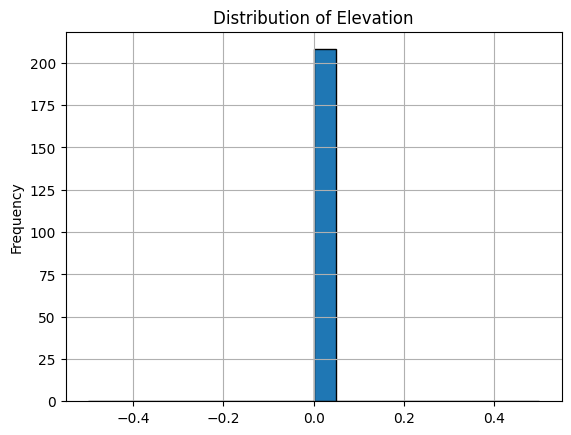

In [32]:
import matplotlib.pyplot as plt

# Plot the distribution of the Elevation_m column
df['Elevation_m'].hist(bins=20, edgecolor='black')
plt.title('Distribution of Elevation')
elevation_counts = df['Elevation_m'].value_counts()
print(elevation_counts)
plt.ylabel('Frequency')
plt.show()

In [ ]:
df 
df concat'
